**Colab Link:** https://tinyurl.com/3tn5whpb

**Team 9**: Chamnan Suon, Daaksha Arun, Parthvi Joshi, Quency Ye

# **Introduction**

## **Motivation**

This project aims to build a data-driven loan default prediction model using algorithms such as Logistic Regression, Decision Trees, Random Forest, and SVM. By combining detailed numeric features (loan amount, interest rate, income, DTI, FICO ranges, revolving balance, etc.) with categorical borrower attributes (term, grade, employment length, home ownership, loan purpose, state, verification status, and more), the model captures complex patterns that traditional underwriting often misses. This allows for a more accurate and adaptive assessment of borrower risk.

From a business perspective, improving default prediction directly enhances portfolio performance by reducing credit losses, increasing approvals for low-risk customers, and streamlining underwriting decisions. The resulting insights also help refine credit policies, improve pricing strategies, and support scalable, faster, and fairer lending operations—ultimately driving stronger financial outcomes and competitive advantage.

## **Data Source and Description**

We obtained our datasource from a user on Kaggle, who collected the data directly from the LendingClub Corporation, a US online marketplace lender, and made it appropriately available on Kaggle platform. We are unable to download directly from the website due to LendingClub's new data download policy.
Dataset Description
- Contains data between June 2007 to December 2018 in all 50 US states
- This dataset includes 152 columns and 1,912,029 rows
- The dataset size is 1.68 GB

Since there are over 150 columns, we are unable to include all column definitions. Hence, below is the filtered data dictionary of the columns we used in our analysis and model predictions.

Column | Description | Data Type | Derived Column
------ | ----------- | --------- | -------
loan_target| A derived column fron loan_status column to binary and to be used in classification models | boolean | Yes
loan_amnt  | The listed amount of the loan applied for by the borrower. If at some point in time, the credit department reduces the loan amount, then it will be reflected in this value | numeric | No
fund_amnt  | The total amount committed to that loan at that point in time | numeric | No
int_rate | Interest Rate on the loan | numeric | No
installment  | The monthly payment owed by the borrower if the loan originates | numeric | No
annual_inc  | The self-reported annual income provided by the borrower during registration|numeric| No
dti  |A ratio calculated using the borrower’s total monthly debt payments on the total debt obligations, excluding mortgage and the requested LC loan, divided by the borrower’s self-reported monthly income|numeric|No
fico_range_low | The lower boundary range the borrower’s FICO at loan origination belongs to|numeric|No
fico_range_high  | The upper boundary range the borrower’s FICO at loan origination belongs to|numeric|No
open_acc  |The number of open credit lines in the borrower's credit file|numeric|No
pub_rec  |Number of derogatory public records|numeric|No
revol_bal  |Total credit revolving balance|numeric|No
revol_util  |Revolving line utilization rate, or the amount of credit the borrower is using relative to all available revolving credit|numeric|No
total_acc  |The total number of credit lines currently in the borrower's credit file|numeric|No
issue_year  |The year which the loan was funded|numeric|No
issue_month  |The month which the loan was funded|No
term  |The number of payments on the loan. Values are in months and can be either 36 or 60|category|no
grade  |LC assigned loan grade|category|No
sub_grade  |LC assigned loan subgrade|category|No
emp_length  |Employment length in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years|category|No
home_ownership  |The home ownership status provided by the borrower during registration or obtained from the credit report. Our values are: RENT, OWN, MORTGAGE, OTHER|category|No
verification_status   |Indicates if income was verified by LC, not verified, or if the income source was verified|category|No
purpose  |A category provided by the borrower for the loan request|category|No
addr_state  |The state provided by the borrower in the loan application|category|No
application_type  |Indicates whether the loan is an individual application or a joint application with two co-borrowers|category|No

## **Executive Summary**

This project uses large-scale LendingClub loan data to predict borrower default risk using machine learning. The dataset was rigorously cleaned by standardizing data types, handling missing values, engineering time-based features, constructing a binary default target, and removing selected state records for consistency, resulting in a high-quality modeling dataset of over 1.9 million loans Exploratory data analysis revealed that default risk is strongly associated with higher interest rates, mid-range debt-to-income ratios (20–40%), higher revolving credit utilization, larger installment payments, and longer loan terms. Loans issued during the 2007–2009 period showed the highest default rates, while more recent loans performed significantly better.

Four models—Logistic Regression, Support Vector Machine, Decision Tree, and Random Forest—were developed using borrower, credit, loan, and payment features. The Decision Tree provided clear interpretability of key risk drivers, while the Random Forest delivered the most stable and accurate predictions by reducing overfitting. Overall, the results confirm that credit quality, repayment capacity, loan pricing, and credit utilization are the strongest predictors of default and demonstrate how machine learning can enhance credit risk assessment and lending decisions.

# **Data Cleaning**

## **Load Data**

In [ ]:
# Mount to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load uncleaned dataset
# Import pandas and load dataset into DataFrame
import pandas as pd
path = '/content/drive/MyDrive/ba810-Team-Project-09/dataset-lendingclub/accepted_2007_to_2018q4/accepted_2007_to_2018Q4.csv'
loan_df = pd.read_csv(path,low_memory=False)

In [ ]:
# Import numpy and print the first 5 rows of dataset
import numpy as np
loan_df.head(5)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Check total rows and columns in the dataset
loan_df.shape

(2260701, 151)

## **Data Cleaning and Handling Missing Values**

- Dropped unneeded columns and normalized missing values to NaN
- Identified mixed-values columns and converted to string type
- Converted date columns data type to date and created new columns: issue_month, issue_year
- Mapped loan_status values and created a binary column loan_target

In [ ]:
# drop unnecessary columns
loan_df.drop(['member_id', 'url', 'zip_code', 'policy_code', 'hardship_type', 'deferral_term', 'hardship_start_date', 'hardship_end_date', 'desc'], axis=1, inplace=True)

In [ ]:
# replace "", " ", "NA", "N/A", "null", ".", "na" with NAN
loan_df = loan_df.replace(["", " ", "NA", "N/A", "null", ".", "na"], pd.NA)

In [ ]:
# Find and list all columns with mixed data types
mixed_cols = [
    col for col in loan_df.columns
    if loan_df[col].map(type).nunique() > 1
]

print(mixed_cols)

['term', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'purpose', 'title', 'addr_state', 'earliest_cr_line', 'initial_list_status', 'last_pymnt_d', 'next_pymnt_d', 'last_credit_pull_d', 'application_type', 'verification_status_joint', 'sec_app_earliest_cr_line', 'hardship_flag', 'hardship_reason', 'hardship_status', 'payment_plan_start_date', 'hardship_loan_status', 'disbursement_method', 'debt_settlement_flag', 'debt_settlement_flag_date', 'settlement_status', 'settlement_date']


In [ ]:
# Convert mixed data type columns to a string data type and remove any whitespace
for col in mixed_cols:
    loan_df[col]=loan_df[col].astype(str).str.strip()
    print(f"Converted column '{col}' to string data type and removed whitespace.")

Converted column 'term' to string data type and removed whitespace.
Converted column 'grade' to string data type and removed whitespace.
Converted column 'sub_grade' to string data type and removed whitespace.
Converted column 'emp_title' to string data type and removed whitespace.
Converted column 'emp_length' to string data type and removed whitespace.
Converted column 'home_ownership' to string data type and removed whitespace.
Converted column 'verification_status' to string data type and removed whitespace.
Converted column 'issue_d' to string data type and removed whitespace.
Converted column 'loan_status' to string data type and removed whitespace.
Converted column 'pymnt_plan' to string data type and removed whitespace.
Converted column 'purpose' to string data type and removed whitespace.
Converted column 'title' to string data type and removed whitespace.
Converted column 'addr_state' to string data type and removed whitespace.
Converted column 'earliest_cr_line' to string da

In [ ]:
# Return data types in each column
for col in loan_df.columns:
    loan_df[col].map(type).value_counts()
    print(f"Column '{col}' data types:\n{loan_df[col].map(type).value_counts()}\n")

Column 'id' data types:
id
<class 'str'>    2260701
Name: count, dtype: int64

Column 'loan_amnt' data types:
loan_amnt
<class 'float'>    2260701
Name: count, dtype: int64

Column 'funded_amnt' data types:
funded_amnt
<class 'float'>    2260701
Name: count, dtype: int64

Column 'funded_amnt_inv' data types:
funded_amnt_inv
<class 'float'>    2260701
Name: count, dtype: int64

Column 'term' data types:
term
<class 'str'>    2260701
Name: count, dtype: int64

Column 'int_rate' data types:
int_rate
<class 'float'>    2260701
Name: count, dtype: int64

Column 'installment' data types:
installment
<class 'float'>    2260701
Name: count, dtype: int64

Column 'grade' data types:
grade
<class 'str'>    2260701
Name: count, dtype: int64

Column 'sub_grade' data types:
sub_grade
<class 'str'>    2260701
Name: count, dtype: int64

Column 'emp_title' data types:
emp_title
<class 'str'>    2260701
Name: count, dtype: int64

Column 'emp_length' data types:
emp_length
<class 'str'>    2260701
Name: 

In [ ]:
# Convert datatype of date columns from string to date
date_cols = ['issue_d','earliest_cr_line','last_pymnt_d','next_pymnt_d','last_credit_pull_d','sec_app_earliest_cr_line','payment_plan_start_date','debt_settlement_flag_date','settlement_date']
for col in date_cols:
  loan_df[col]=pd.to_datetime(loan_df[col], errors='coerce')
  print(f"Converted column '{col}' to datetime.")


/tmp/ipython-input-944385452.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  loan_df[col]=pd.to_datetime(loan_df[col], errors='coerce')


Converted column 'issue_d' to datetime.


/tmp/ipython-input-944385452.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  loan_df[col]=pd.to_datetime(loan_df[col], errors='coerce')


Converted column 'earliest_cr_line' to datetime.
Converted column 'last_pymnt_d' to datetime.


/tmp/ipython-input-944385452.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  loan_df[col]=pd.to_datetime(loan_df[col], errors='coerce')
/tmp/ipython-input-944385452.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  loan_df[col]=pd.to_datetime(loan_df[col], errors='coerce')


...

Converted column 'payment_plan_start_date' to datetime.


/tmp/ipython-input-944385452.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  loan_df[col]=pd.to_datetime(loan_df[col], errors='coerce')


Converted column 'debt_settlement_flag_date' to datetime.


/tmp/ipython-input-944385452.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  loan_df[col]=pd.to_datetime(loan_df[col], errors='coerce')


Converted column 'settlement_date' to datetime.


In [ ]:
# Confirmed data type
loan_df[['issue_d','earliest_cr_line','last_pymnt_d','next_pymnt_d','last_credit_pull_d','sec_app_earliest_cr_line','payment_plan_start_date','debt_settlement_flag_date','settlement_date']].dtypes

,0
issue_d,datetime64[ns]
earliest_cr_line,datetime64[ns]
last_pymnt_d,datetime64[ns]
next_pymnt_d,datetime64[ns]
last_credit_pull_d,datetime64[ns]
sec_app_earliest_cr_line,datetime64[ns]
payment_plan_start_date,datetime64[ns]
debt_settlement_flag_date,datetime64[ns]
settlement_date,datetime64[ns]


In [ ]:
# Create new columns issue month and issue year
loan_df['issue_year'] = loan_df['issue_d'].dt.year.astype('Int64')
loan_df['issue_month'] = loan_df['issue_d'].dt.month.astype('Int64')
# Confirm
loan_df[['issue_d', 'issue_year', 'issue_month']].head(5)

,issue_d,issue_year,issue_month
0,2015-12-01,2015,12
1,2015-12-01,2015,12
2,2015-12-01,2015,12
3,2015-12-01,2015,12
4,2015-12-01,2015,12


## **Remove Seven States Data**
Upon discussion with team 10, we will remove data from the following states from our dataset
- Maine ME
- Vermont VT
- ⁠New Hampshire NH
- ⁠Massachusetts MA
- ⁠Connecticut CT
- ⁠Rhode Island RI
- ⁠New York NY

In [ ]:
# Remove data from New England states and NY state
# df = df[~df['state'].isin(['New Mexico', 'New York'])]
loan_df = loan_df[~loan_df['addr_state'].isin(['ME','VT','NH','MA','CT','RI','NY'])]
# (2260701, 151)

In [ ]:
# Confirm data from above states are removed from the dataset
# Data over 300k rows were removed
loan_df['addr_state'].unique()

array(['PA', 'SD', 'IL', 'NJ', 'GA', 'MN', 'SC', 'TX', 'NC', 'CA', 'VA',
       'AZ', 'IN', 'MD', 'KS', 'NM', 'AL', 'WA', 'MO', 'OH', 'LA', 'FL',
       'CO', 'MI', 'TN', 'DC', 'WI', 'HI', 'DE', 'NE', 'OR', 'AR', 'MT',
       'NV', 'WV', 'WY', 'OK', 'KY', 'MS', 'UT', 'ND', 'AK', 'nan', 'ID',
       'IA'], dtype=object)

Over 300k rows of data were removed after excluding these 7 states.

## **Convert target feature to binary**

In [ ]:
# Check unique values in target feature loan_status and decide which should be considered as default or repay
loan_df['loan_status'].value_counts()

,count
loan_status,
Fully Paid,935385
Current,756308
Charged Off,232376
Late (31-120 days),18374
In Grace Period,7150
Late (16-30 days),3711
Does not meet the credit policy. Status:Fully Paid,1654
Does not meet the credit policy. Status:Charged Off,663
nan,33


In [ ]:
# Create binary target feature
# Create a dict mapping values in loan_status to binary
loan_status_map ={
    'Fully Paid': 0,
    'Current': 0,
    'Charged Off': 1,
    'Late (31-120 days)': 1,
    'Late (16-30 days)': 0,
    'In Grace Period': 0,
    'Does not meet the credit policy. Status:Fully Paid': 0,
    'Does not meet the credit policy. Status:Charged Off': 1,
    'Default': 1,
}

# Map to binary target column loan_target
loan_df['loan_target'] = loan_df['loan_status'].map(loan_status_map)
# Drop rows with missing target (OK to drop 33 missing target values)
loan_df = loan_df.dropna(subset=['loan_target'])
loan_df['loan_target'] = loan_df['loan_target'].astype(int)



In [ ]:
# Check and confirm new loan_target column
loan_df[['loan_target', 'loan_status']].head(10)

,loan_target,loan_status
0,0,Fully Paid
1,0,Fully Paid
2,0,Fully Paid
3,0,Current
4,0,Fully Paid
5,0,Fully Paid
6,0,Fully Paid
7,0,Fully Paid
8,0,Fully Paid
10,0,Current


In [ ]:
# # Set threshold and drop columns with missing values greater than the threshold
# threshold = 1500000 # adjust this until reach desired outcome
# cols_to_drop = loan_df.columns[loan_df.isnull().sum() > threshold]
# loan_df = loan_df.drop(columns=cols_to_drop)

In [ ]:
# Count missing values in each column
loan_df.isnull().sum().sort_values(ascending=False)

,0
mths_since_last_major_derog,1451407
mths_since_recent_revol_delinq,1321649
next_pymnt_d,1167761
mths_since_last_delinq,1005962
il_util,921911
...,...
debt_settlement_flag,0
settlement_status,0
issue_year,0
issue_month,0


In [ ]:
# ========= ONLY RUN THIS IF YOU WANT TO DOWNLOAD THE CLEANED DATASET =========
# Create downloadable cleaned dataset
# from google.colab import files

# loan_df.to_csv('loan_data_cleaned.csv', index=False)
# files.download('loan_data_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Exploratory Data Analysis**

In order to better understand our dataset, we conducted an Exploratory Data Analysis (EDA). The dataset contains over 150 variables, which means not all of them are suitable or necessary for modeling. Through EDA, we can examine data quality, understand variable distributions and relationships, and identify the most relevant features for subsequent analysis and modeling.

Before performing the analysis, we reviewed the official data documentation to clearly understand the definition and meaning of each variable. Based on their characteristics and analytical purpose, we grouped the variables into the following categories:

Borrower Characteristics include basic demographic and financial information about the borrowers, such as FICO credit score, employment length, home ownership status, annual income, number of mortgage accounts, and other personal credit-related information. These variables help describe the overall profile of borrowers.

Loan Characteristics focus on information related to the loan itself, such as loan amount distribution, interest rate, loan term, and issue date. These variables help us understand the structure and pricing of the loans.

Debt and Income Analysis examines the relationship between borrowers’ debt and income. By analyzing income distribution and debt-related variables such as debt-to-income (DTI) ratio, we evaluate borrowers’ repayment capacity and financial pressure.

Credit Behavior focuses on borrowers’ credit usage and credit risk, such as the number of credit lines, utilization rate, and whether the borrower defaulted. Compared with basic borrower information, these variables directly reflect borrowers’ credit management behavior and risk level.

Payment Performance describes borrowers’ actual repayment behavior, including installment payments, payment history, hardship status, and loan issue status. These variables help evaluate loan performance and borrower reliability over time.

This EDA provides a solid foundation for feature selection and supports the subsequent modeling and risk analysis.

In [ ]:
# Mount to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Quencys laptop
# Load cleaned dataset into DataFrame for exploratory data analysis
import pandas as pd
path = '/content/drive/MyDrive/810  machine learning Project/Copy of loan_data_cleaned.csv'
loan_df = pd.read_csv(path,low_memory=False)

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
loan_df.shape

(1955652, 116)

In [ ]:
list(loan_df.columns)

['id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'purpose',
 'title',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'application_type',
 'verification_status_joint',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_bal',
 'open_acc_6m',
 'open_act_i

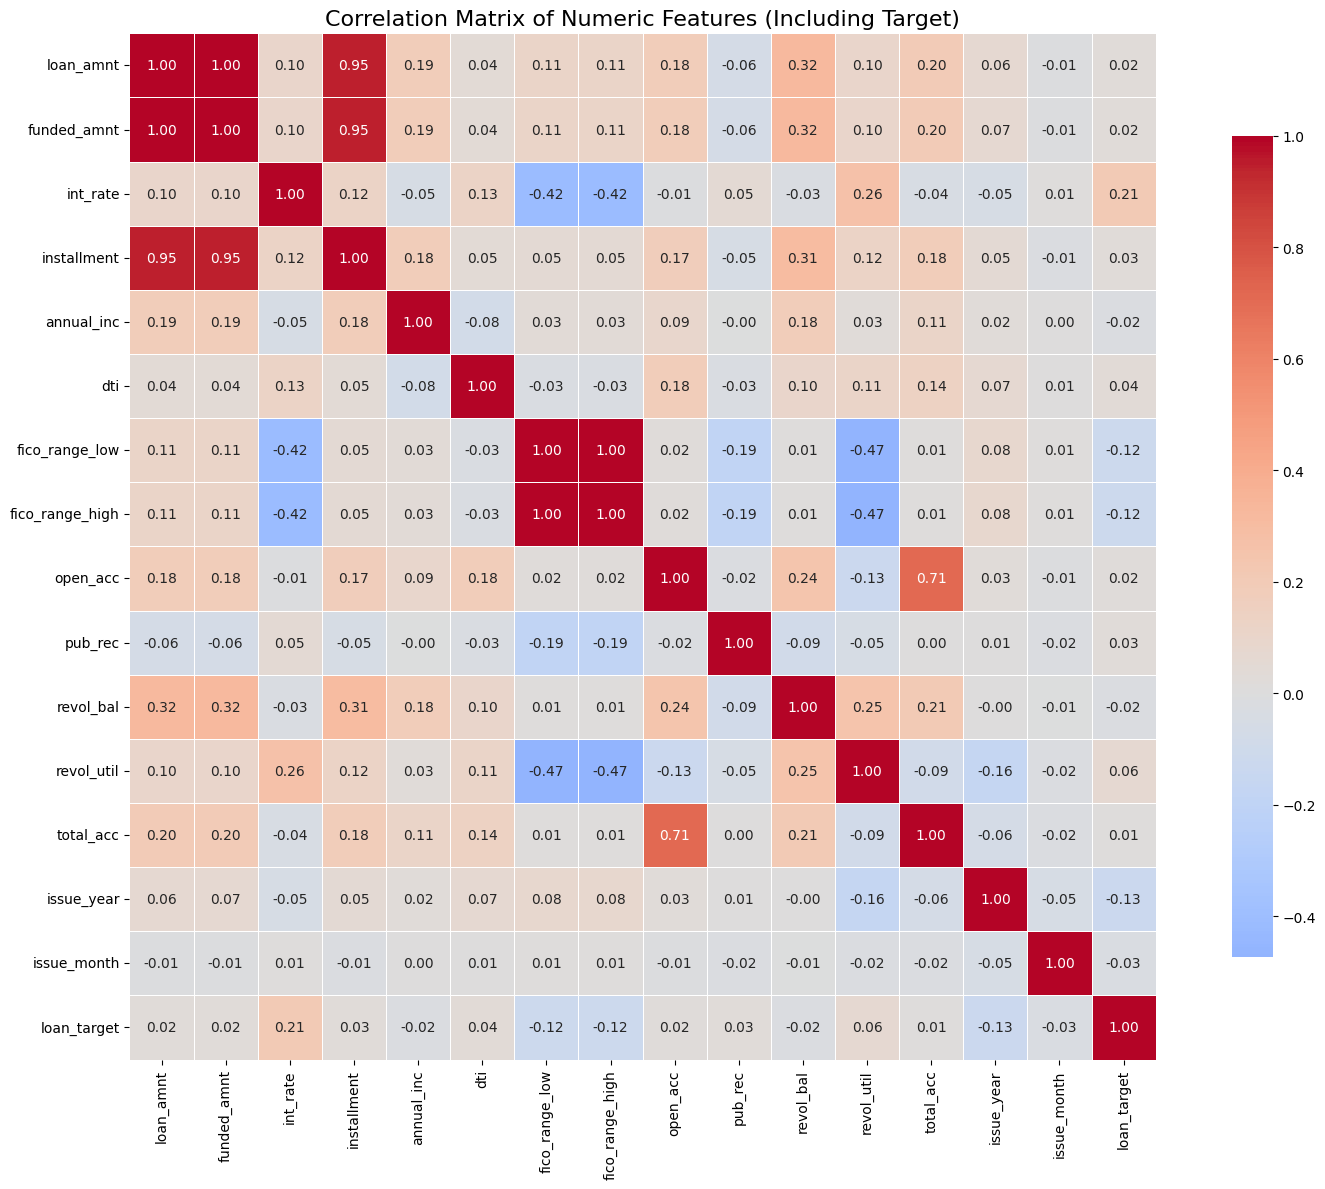


Correlations with loan_target (sorted):
loan_target        1.000000
int_rate           0.208176
revol_util         0.062471
dti                0.035247
pub_rec            0.032208
installment        0.030068
loan_amnt          0.024317
funded_amnt        0.024206
open_acc           0.017286
total_acc          0.013878
annual_inc        -0.022863
revol_bal         -0.023095
issue_month       -0.026936
fico_range_high   -0.121386
fico_range_low    -0.121388
issue_year        -0.129415
Name: loan_target, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric features + target variable
numeric_features = [
    "loan_amnt",
    "funded_amnt",
    "int_rate",
    "installment",
    "annual_inc",
    "dti",
    "fico_range_low",
    "fico_range_high",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "issue_year",
    "issue_month",
    "loan_target"  # Your actual target variable name
]

# Compute correlation
corr = loan_df[numeric_features].corr()

# Plot heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',  # Format to 2 decimal places for readability
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix of Numeric Features (Including Target)", fontsize=16)
plt.tight_layout()
plt.show()

# Bonus: Show correlations with target specifically
print("\nCorrelations with loan_target (sorted):")
print(corr['loan_target'].sort_values(ascending=False))

In [ ]:
# numeric features + target
num_target_corr = loan_df[numeric_features + ['loan_target']].corr()['loan_target'].sort_values()

print(num_target_corr)


issue_year        -0.129415
fico_range_low    -0.121388
fico_range_high   -0.121386
issue_month       -0.026936
revol_bal         -0.023095
annual_inc        -0.022863
total_acc          0.013878
open_acc           0.017286
funded_amnt        0.024206
loan_amnt          0.024317
installment        0.030068
pub_rec            0.032208
dti                0.035247
revol_util         0.062471
int_rate           0.208176
loan_target        1.000000
Name: loan_target, dtype: float64


In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

categorical_features = [
    "term",
    "grade",
    "sub_grade",
    "emp_length",
    "home_ownership",
    "verification_status",
    "purpose",
    "addr_state",
    "application_type"
]

chi2_results = []
for col in categorical_features:
    table = pd.crosstab(loan_df[col], loan_df["loan_target"])
    chi2, p, dof, exp = chi2_contingency(table)
    chi2_results.append([col, chi2, p])  # Add chi2 value too

chi2_df = pd.DataFrame(chi2_results, columns=["Feature", "Chi2", "p_value"])
chi2_df = chi2_df.sort_values("p_value")
chi2_df['Significant'] = chi2_df['p_value'] < 0.05  # Add significance flag
print(chi2_df)

               Feature           Chi2        p_value  Significant
0                 term   15534.709084   0.000000e+00         True
1                grade  103530.033191   0.000000e+00         True
2            sub_grade  107396.195256   0.000000e+00         True
4       home_ownership    5712.529912   0.000000e+00         True
6              purpose    5167.964212   0.000000e+00         True
5  verification_status   17586.695057   0.000000e+00         True
7           addr_state    2585.112727   0.000000e+00         True
8     application_type    3449.532309   0.000000e+00         True
3           emp_length     604.597574  1.822237e-123         True


Dropping highly correlated features: ['funded_amnt', 'fico_range_high']


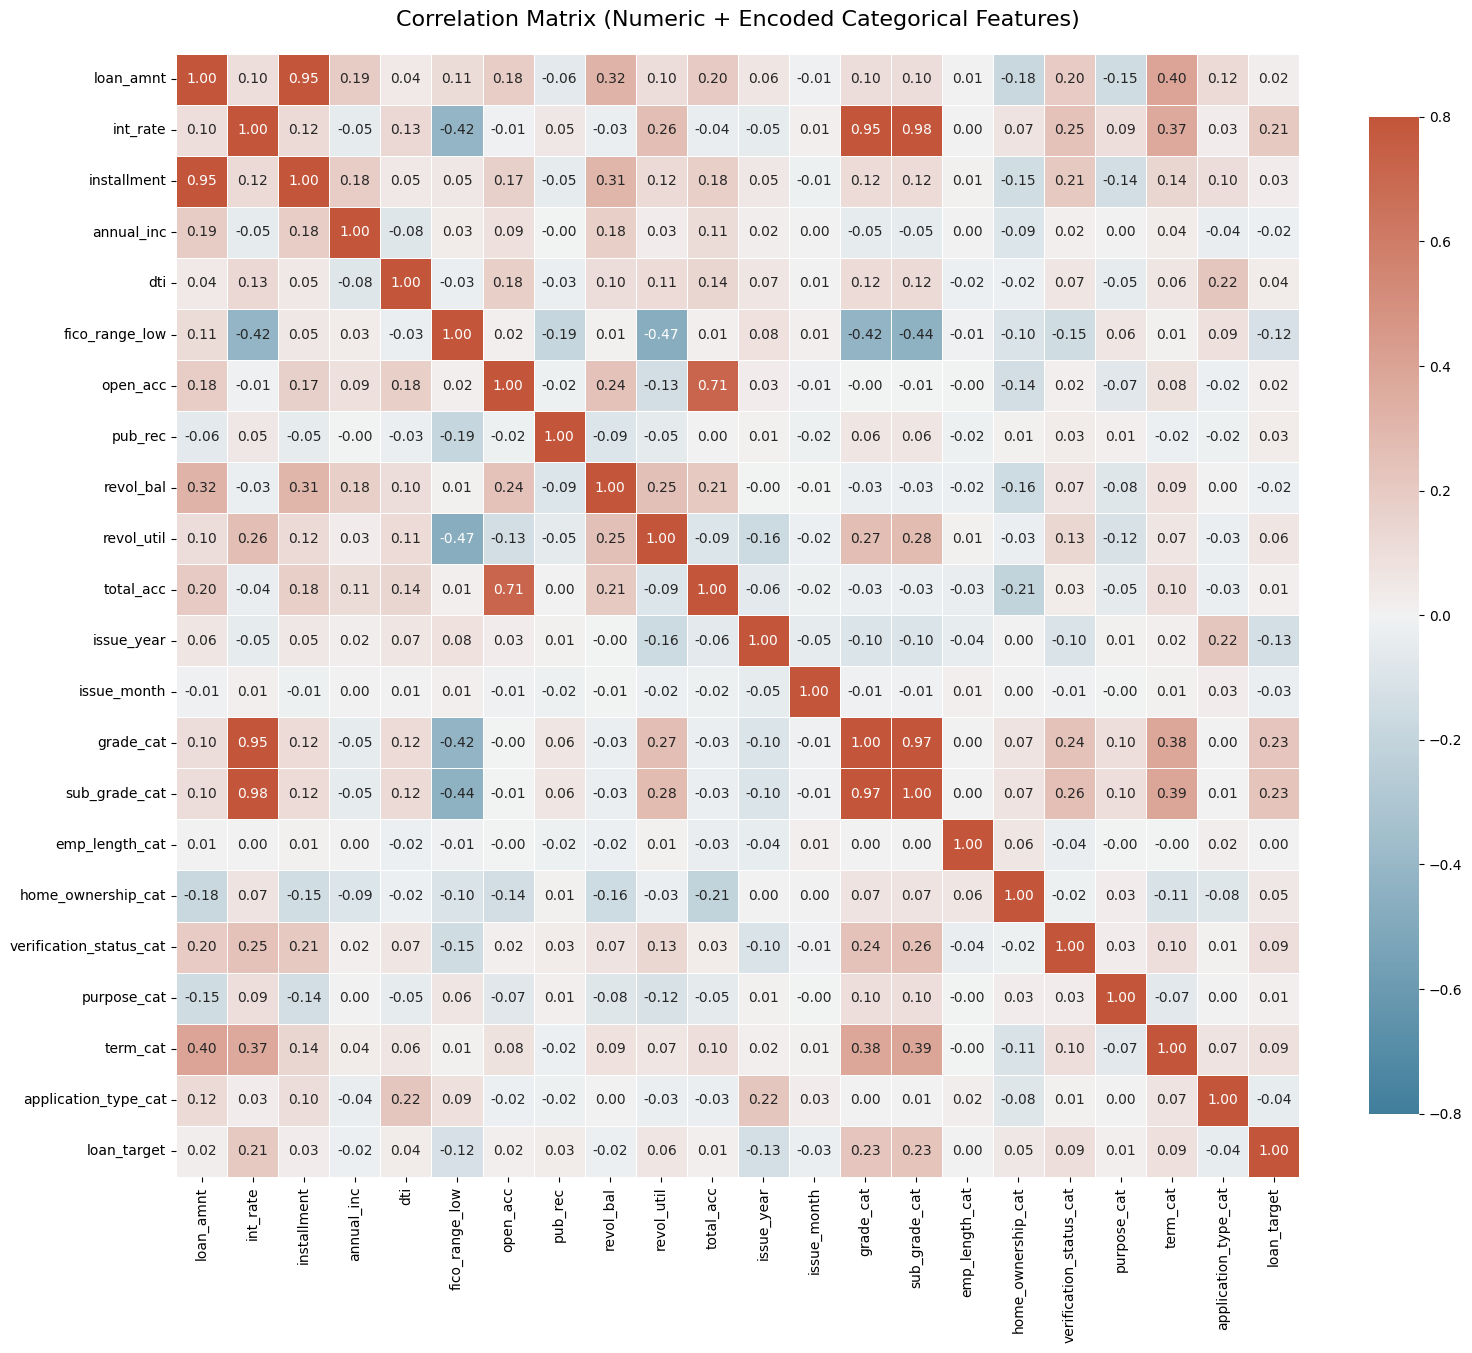


Correlations with loan_target (sorted by absolute value):
sub_grade_cat              0.232718
grade_cat                  0.228894
int_rate                   0.208176
issue_year                -0.129415
fico_range_low            -0.121388
verification_status_cat    0.094613
term_cat                   0.089128
revol_util                 0.062471
home_ownership_cat         0.052924
application_type_cat      -0.042002
dti                        0.035247
pub_rec                    0.032208
installment                0.030068
issue_month               -0.026936
loan_amnt                  0.024317
revol_bal                 -0.023095
annual_inc                -0.022863
open_acc                   0.017286
purpose_cat                0.014996
total_acc                  0.013878
emp_length_cat             0.001767
Name: loan_target, dtype: float64

Top 5 Positive Correlations with loan_target:
sub_grade_cat              0.232718
grade_cat                  0.228894
int_rate                   0.208

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Convert categorical features to numeric codes
categorical_to_encode = ['grade', 'sub_grade', 'emp_length', 'home_ownership',
                         'verification_status', 'purpose', 'term', 'application_type']

for col in categorical_to_encode:
    loan_df[col] = loan_df[col].astype('category')
    loan_df[f'{col}_cat'] = loan_df[col].cat.codes

# Step 2: Select features for correlation analysis
numeric_features = [
    "loan_amnt",
    "funded_amnt",
    "int_rate",
    "installment",
    "annual_inc",
    "dti",
    "fico_range_low",
    "fico_range_high",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "issue_year",
    "issue_month"
]

categorical_encoded = [
    "grade_cat",
    "sub_grade_cat",
    "emp_length_cat",
    "home_ownership_cat",
    "verification_status_cat",
    "purpose_cat",
    "term_cat",
    "application_type_cat"
]

# Combine all features including target
all_features = numeric_features + categorical_encoded + ["loan_target"]

# Step 3: Calculate correlation matrix
corr = loan_df[all_features].corr()

# Step 4: Identify and drop highly correlated features (correlation = 1.0, excluding diagonal)
# Create a mask for upper triangle
upper_triangle = np.triu(np.ones(corr.shape), k=1).astype(bool)
upper_corr = corr.where(upper_triangle)

# Find features with correlation = 1.0
to_drop = [column for column in upper_corr.columns if any(upper_corr[column] >= 0.99)]

print(f"Dropping highly correlated features: {to_drop}")

# Drop the redundant features
features_to_keep = [f for f in all_features if f not in to_drop]
corr_filtered = loan_df[features_to_keep].corr()

# Step 5: Create correlation heatmap
plt.figure(figsize=(16, 14))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap
sns.heatmap(
    corr_filtered,
    cmap=cmap,
    vmax=0.8,
    vmin=-0.8,
    annot=True,
    fmt='.2f',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix (Numeric + Encoded Categorical Features)", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Step 6: Show correlations with target specifically
print("\n" + "="*50)
print("Correlations with loan_target (sorted by absolute value):")
print("="*50)
target_corr = corr_filtered['loan_target'].drop('loan_target').sort_values(key=abs, ascending=False)
print(target_corr)

# Step 7: Separate top positive and negative correlations
print("\n" + "="*50)
print("Top 5 Positive Correlations with loan_target:")
print("="*50)
print(target_corr.nlargest(5))

print("\n" + "="*50)
print("Top 5 Negative Correlations with loan_target:")
print("="*50)
print(target_corr.nsmallest(5))

## **Borrowers Characteristics**

### **FICO Score Distribution**

In [ ]:
# check the range about FICO scores
print("FICO Low: ", loan_df['fico_range_low'].min(), "-", loan_df['fico_range_low'].max())
print("FICO High:", loan_df['fico_range_high'].min(), "-", loan_df['fico_range_high'].max())


FICO Low:  610.0 - 845.0
FICO High: 614.0 - 850.0


In [ ]:
loan_df[['fico_range_low', 'fico_range_high']].describe().round(2)


,fico_range_low,fico_range_high
count,1955652.00,1955652.00
mean,698.44,702.44
std,32.94,32.94
min,610.00,614.00
25%,675.00,679.00
50%,690.00,694.00
75%,715.00,719.00
max,845.00,850.00


In [ ]:
#Since the FICO score is range, so calculate the average number for the next step
loan_df['fico_avg'] = (loan_df['fico_range_low'] + loan_df['fico_range_high']) / 2


In [ ]:
#calculate the count for fico score, and the percentage

bins = [0, 579, 669, 739, 799, 850]
labels = ['Poor (<579)', 'Fair (580-669)', 'Good (670-739)', 'Very Good (740-799)', 'Exceptional (>800)']
loan_df['fico_category'] = pd.cut(loan_df['fico_avg'], bins=bins, labels=labels)
fico_counts = loan_df['fico_category'].value_counts(sort=False) #keep order, otherwise the output will be DESC
fico_percent = (fico_counts / loan_df.shape[0]) * 100
fico_summary = pd.DataFrame({'Count': fico_counts, 'Percentage': fico_percent.round(2)})
print(fico_summary)


                       Count  Percentage
fico_category                           
Poor (<579)                0        0.00
Fair (580-669)        320245       16.38
Good (670-739)       1393581       71.26
Very Good (740-799)   215278       11.01
Exceptional (>800)     26548        1.36


FICO scores are commonly used by financial companies to assess a borrower’s creditworthiness. A higher FICO score indicates lower risk and a greater likelihood of qualifying for loans, while a lower score indicates higher risk. The FICO score ranges from 300 to 850:
- 300–579: Poor
- 580–669: Fair
- 670–739: Good
- 740–799: Very Good
- 800+: Exceptional

Based on the data, the majority of borrowers fall in the mid-range, from 675 to 719, which corresponds to Fair and Good categories. From the percentage analysis, over 82% of borrowers are in the Good or higher categories, while about 16.25% fall into the Fair category, which warrants attention.

What is a FICO® Score? https://www.myfico.com/credit-education/what-is-a-fico-score

### **Employment Group**

In [ ]:
loan_df['emp_length'].value_counts(sort=True)

,count
emp_length,
10+ years,644755
2 years,176231
< 1 year,165110
3 years,155863
1 year,128539
5 years,120646
4 years,118023
6 years,89126
7 years,80212


In [ ]:
# create a new column, do not change the original column/ Convert emp_length into numeric
mapping = {
    '< 1 year': 0,
    '1 year': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    '10+ years': 10
}

loan_df['emp_len_num'] = loan_df['emp_length'].map(mapping)


In [ ]:
bins = [-1, 1, 3, 6, 9, 20]
labels = ['New (0–1)', 'Early (2–3)', 'Mid (4–6)', 'Senior (7–9)', 'Very Senior (10+)']
loan_df['emp_category'] = pd.cut(loan_df['emp_len_num'], bins=bins, labels=labels)
loan_df['emp_category'].value_counts()

summary = pd.DataFrame({
    'Count': counts,
    'Percent (%)': percent.round(2)
})

summary


,Count,Percent (%)
emp_category,,
Very Senior (10+),644755,35.30
Early (2–3),332094,18.18
Mid (4–6),327795,17.94
New (0–1),293649,16.08
Senior (7–9),228417,12.50


Most borrowers in the dataset have substantial work experience. The largest group is Very Senior (10+ years) with 748,005 borrowers, showing that long job stability is common among loan applicants.However, the Senior (7–9 years) category has 264,004 borrowers, making it the smallest of the experienced groups.

The Early (2–3 years) and Mid (4–6 years) groups with 384,430 and 378,931 borrowers respectively. The New (0–1 year) group includes 338,391 borrowers, meaning a smaller portion of applicants are at the beginning of their employment.

Overall, the majority of borrowers have over 10 years of employment, suggesting the dataset mainly consists of applicants with stable or established job histories.

### **Annual Income Distribution**

In [ ]:
loan_df['annual_inc'].value_counts()

In [ ]:
loan_df['annual_inc'].describe()

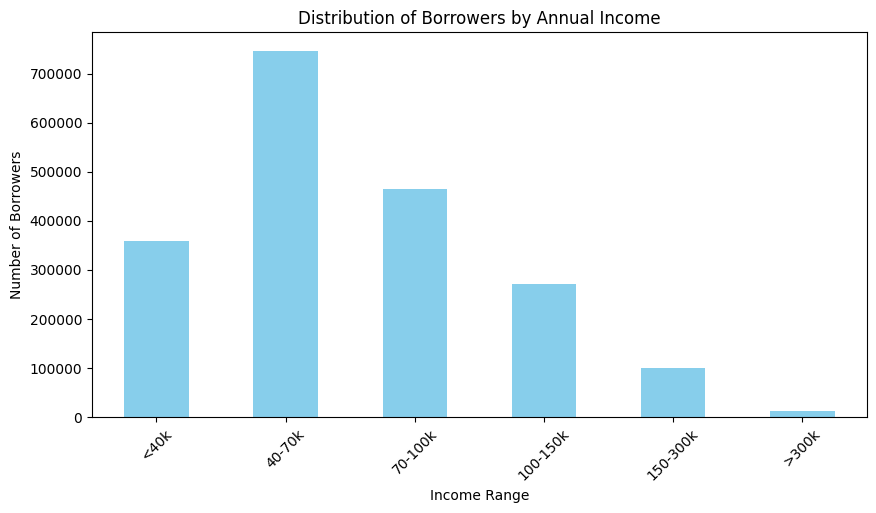

In [ ]:
# Define income groups
bins = [0, 40000, 70000, 100000, 150000, 300000, 1e9]  # last bin captures all extreme values
labels = ['<40k', '40-70k', '70-100k', '100-150k', '150-300k', '>300k']
loan_df['income_group'] = pd.cut(loan_df['annual_inc'], bins=bins, labels=labels)

#Count borrowers per income group
income_counts = loan_df['income_group'].value_counts(sort=False)

#plot the bar chart
plt.figure(figsize=(10,5))
income_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Borrowers by Annual Income')
plt.xlabel('Income Range')
plt.ylabel('Number of Borrowers')
plt.xticks(rotation=45)
plt.show()


In [ ]:
income_counts = loan_df['income_group'].value_counts()
income_percent = loan_df['income_group'].value_counts(normalize=True) * 100

income_summary = pd.DataFrame({
    'Count': income_counts,
    'Percent (%)': income_percent.round(2)
})

income_summary


,Count,Percent (%)
income_group,,
40-70k,746503,38.20
70-100k,465352,23.81
<40k,358279,18.33
100-150k,270735,13.85
150-300k,101251,5.18
>300k,11972,0.61


The annual incomes of borrowers vary widely, ranging from 0 to 110,000,000, with a mean of around 77992 and median of 65000.

After grouping incomes into ranges, we observe that the majority of borrowers earn between 40,000 and 70,000, followed by those earning 70,000 to 100,000, and then those earning less than 40,000. A small number of borrowers have extremely high incomes, which skews the mean above the median.

This distribution reflects typical borrower profiles: most borrowers fall into moderate income ranges, which aligns with the common patterns of loan applications, while very high-income borrowers represent only a tiny portion of the dataset.

### **Mortgage Accounts Distribution and Default Rates**


In [ ]:
#create the group
bins = [0, 1, 3, 5, 10, loan_df['mort_acc'].max()]
labels = ['0', '1-2', '3-4', '5-9', '10+']

mort_group = pd.cut(loan_df['mort_acc'], bins=bins, labels=labels, include_lowest=True)

# Distribution (optional)
mort_percent = mort_group.value_counts(normalize=True).sort_index() * 100
print(mort_percent.round(2))


mort_acc
0      58.37
1-2    25.99
3-4    11.15
5-9     4.31
10+     0.19
Name: proportion, dtype: float64


In [ ]:
#Default rate by mortgage-account group
mort_default = (
    loan_df.groupby(pd.cut(loan_df['mort_acc'], bins=bins, labels=labels, include_lowest=True),observed=False)['loan_target']
           .mean() * 100
)

print(mort_default.round(2))


mort_acc
0      13.96
1-2    11.37
3-4    10.90
5-9    10.69
10+    10.13
Name: loan_target, dtype: float64


The distribution of mortgage accounts is highly concentrated, borrowers with 0–1 mortgage make up almost 60% of the dataset, followed by those with 1–2 mortgages at about 25.19%. In terms of the relationship with default, the highest default rate appears among borrowers without any mortgage accounts, at 13.39%. However, one important point to notice is that borrowers with more than 10 mortgages show an unusually high default rate, which stands out compared to the other groups.

## **Loan Characteristics**

### **Loan Amount Distribution**

In [ ]:
loan_df[['loan_amnt', 'int_rate']].describe()


,loan_amnt,int_rate
count,1.955652e+06,1.955652e+06
mean,1.505314e+04,1.309220e+01
std,9.214372e+03,4.827624e+00
min,5.000000e+02,5.310000e+00
25%,8.000000e+03,9.490000e+00
50%,1.297500e+04,1.262000e+01
75%,2.000000e+04,1.599000e+01
max,4.000000e+04,3.099000e+01


/tmp/ipython-input-4043518692.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_int_rate = loan_df.groupby('loan_amnt_group')['int_rate'].mean()


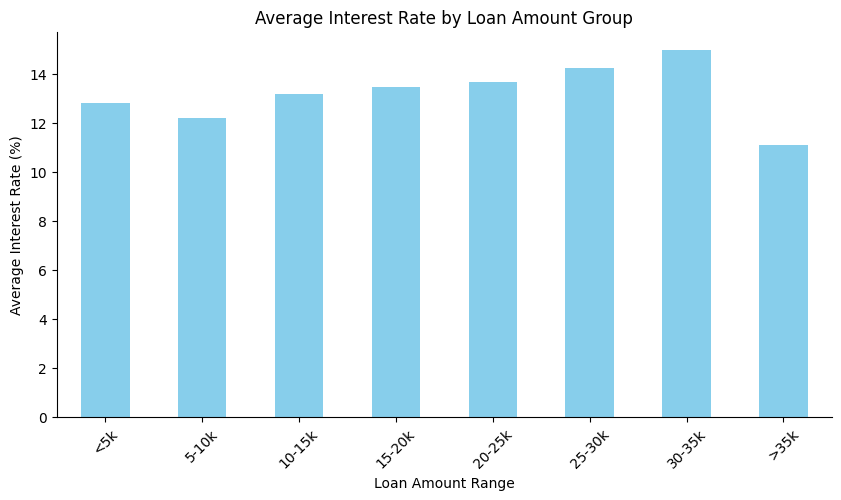

In [ ]:
# Since the dataset has millions of points, so define these loan amount with bins
bins = [0, 5000, 10000, 15000, 20000, 25000, 30000, 35000, 1e6]
labels = ['<5k', '5-10k', '10-15k', '15-20k', '20-25k', '25-30k', '30-35k', '>35k']

loan_df['loan_amnt_group'] = pd.cut(loan_df['loan_amnt'], bins=bins, labels=labels)

# Calculate average interest rate per group
avg_int_rate = loan_df.groupby('loan_amnt_group')['int_rate'].mean()


# Plot
plt.figure(figsize=(10,5))
avg_int_rate.plot(kind='bar', color='skyblue')
plt.title('Average Interest Rate by Loan Amount Group')
plt.xlabel('Loan Amount Range')
plt.ylabel('Average Interest Rate (%)')
plt.xticks(rotation=45)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()


The loan amounts range from 500 to 15,000 and a median of 12900. Interest rates vary from 5.31% to 30.99%, with an average rate of 13.1%. Most loans fall between 8,000 and 20,000, represent most part of borrowes.

According to the bar chart, the interest rate is generally between 12% and 16% for most loan amounts. Loans in the 30,000–35,000 range have slightly higher interest rates, while loans above 35,000 have lower rates. This pattern suggests that moderate to high loan amounts dominate the dataset, and extreme loan sizes are less common and may have different interest rate conditions.

### **The Relative Analysis Between High-rate and Default rate**

In [ ]:
# Average interest rate for each target group
loan_df.groupby('loan_target')['int_rate'].mean()


,int_rate
loan_target,
0,12.706167
1,15.708598


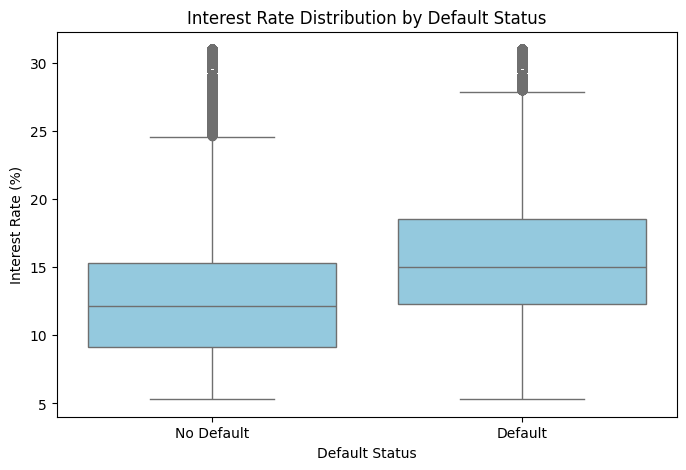

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='loan_target', y='int_rate',color='skyblue', data=loan_df)
plt.xticks([0,1], ['No Default', 'Default'])
plt.title('Interest Rate Distribution by Default Status')
plt.xlabel('Default Status')
plt.ylabel('Interest Rate (%)')
plt.show()


According to the analysis of interest rate and default status, borrowers with higher interest rates are more likely to default. The average interest rate for borrowers who did not default is 12.71%, while for those who defaulted it is 15.70%.

The boxplot confirms this pattern: the median and interquartile range of interest rates are higher for defaulted borrowers compared to non-defaulted borrowers. Although there are outliers in both groups, the overall trend clearly shows that higher-rate loans are associated with a greater risk of default.

### **Comparison between Loan Term and Interest Rate**

In [ ]:
loan_df['term'].value_counts(sort=True)

,count
term,
36 months,1389721
60 months,565931


In [ ]:
interest_summary = loan_df.groupby('term')['int_rate'].describe()
print(interest_summary)


               count       mean       std   min    25%    50%    75%    max
term                                                                       
36 months  1389721.0  11.942981  4.287076  5.31   8.24  11.49  14.46  30.99
60 months   565931.0  15.914258  4.919102  5.31  12.62  15.05  18.94  30.99


In [ ]:
# Contingency table: employment category vs loan term
emp_term_counts = pd.crosstab(loan_df['emp_category'], loan_df['term'])
# print(emp_term_counts)
# Normalize to see proportion of 36 vs 60 months per employment category
emp_term_percent = pd.crosstab(loan_df['emp_category'], loan_df['term'], normalize='index') * 100
print(emp_term_percent.round(2))


longer-term loans tend to have higher interest rates, which is consistent with expectations. Specifically, 36-month loans have a mean interest rate of 11.94%, while 60-month loans have a substantially higher mean rate of 15.92%. This pattern is also reflected in the quartiles: the 25th, 50th, and 75th percentiles for 60-month loans are all higher than those for 36-month loans, indicating that longer-term loans generally carry higher rates across the board.

cross different employment categories, most borrowers prefer the shorter 36-month term, with approximately 70% choosing it, while the remaining 26–32% opt for the longer 60-month term.

## **Debt and Income Ratios**

### **DTI Distribution**

In [ ]:
loan_df['dti'].value_counts(sort=True)
#loan_df['term'].value_counts(sort=True)

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(loan_df['dti'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of DTI')
plt.xlabel('DTI')
plt.ylabel('Number of Loans')
plt.show()

In [ ]:
# Create DTI groups
bins = [0, 20, 40, 60, 100]
labels = ['<20', '20-40', '40-60', '>60']

# Make sure the grouped column exists
loan_df['dti_group'] = pd.cut(
    loan_df['dti'],          # or whatever your DTI column is called
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False              # [0,20), [20,40) ... adjust if you prefer
)

# Contingency table of DTI groups (overall counts)
dti_counts = loan_df['dti_group'].value_counts().sort_index()

# Normalize to get percentage
dti_percent = loan_df['dti_group'].value_counts(normalize=True).sort_index() * 100
print(dti_percent.round(2))


dti_group
<20      58.00
20-40    40.84
40-60     0.89
>60       0.27
Name: proportion, dtype: float64


DTI is stands for Debt-to-Income ratio, and it is a way to evaluate the borrowers' ability to manage monthly paments and repay debts.

Approximately 99% of borrowers in the dataset have a DTI below 40%, meaning most borrowers carry a relatively low or moderate debt burden. Only about 1% have a DTI above 40, suggesting that lenders rarely approve loans for very high DTI borrowers, likely due to higher repayment risk.

### **The Relative Analysis between DTI and  Default Rates**

In [ ]:
summary = (
    loan_df.groupby('dti_group', observed=True)
           .agg(
               total_borrowers = ('dti_group', 'count'),
               total_defaults = ('loan_target', 'sum'),
               default_rate = ('loan_target', 'mean')
           )
)

summary['default_rate'] = (summary['default_rate'] * 100).round(2)

print(summary)


           total_borrowers  total_defaults  default_rate
dti_group                                               
<20                1132012          126253         11.15
20-40               797066          122722         15.40
40-60                17291            1758         10.17
>60                   5309             435          8.19


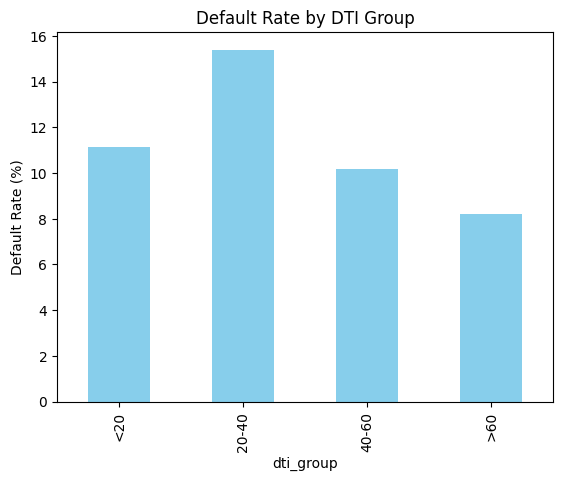

In [ ]:
default_rate = loan_df.groupby('dti_group', observed=True)['loan_target'].mean() * 100

default_rate.plot(kind='bar',color='skyblue')
plt.ylabel("Default Rate (%)")
plt.title("Default Rate by DTI Group")
plt.show()


Borrowers with a DTI of 20–40% show the highest default rate, at 15.42% which is higher than all other DTI groups. In comparison, low DTI borrowers (<20%) have an 11.21% default rate, while high-DTI groups such as 40–60% (10.20%) and >60% (8.20%) actually show lower default rates.

This pattern suggests that in this dataset, default risk does not increase with higher DTI; instead, the mid-range DTI group (20–40%) is the most risky, while extremely high-DTI borrowers (>40%) may be fewer in number and potentially more carefully screened before receiving loans.

## **Credit History**

### **Credit Utilization**

In [ ]:
loan_df['revol_util'].value_counts(sort=True)

,count
revol_util,
0.00,11364
57.00,3741
59.00,3739
48.00,3730
51.00,3659
...,...
58.77,1
70.26,1
34.89,1


In [ ]:
# Create utilization groups (inline, without adding a new column)
bins = [0, 20, 40, 60, 80, 100]
labels = ['<20', '20-40', '40-60', '60-80', '>80']

# Generate categories temporarily, do not use loan_df['util_group']!!!
util_group = pd.cut(loan_df['revol_util'], bins=bins, labels=labels, include_lowest=True)

# Contingency table: counts
util_counts = util_group.value_counts().sort_index()

# Normalize to get percentage
util_percent = util_group.value_counts(normalize=True).sort_index() * 100

print(util_percent.round(2))


revol_util
<20      12.81
20-40    23.27
40-60    27.42
60-80    23.14
>80      13.36
Name: proportion, dtype: float64


The distribution of revolving credit utilization shows that borrowers are spread across all utilization levels, with the largest share falling into the 20–40% range (23.31%) and 40–60% range (27.40%). Lower-utilization borrowers (<20%) represent 12.87%, while higher-utilization groups (60–80% and >80%) account for 23.08% and 13.34%, respectively.

This pattern indicates a strong positive relationship between credit utilization and default risk: as borrowers use more of their available credit, they are more likely to default, reflecting financial stress and reduced repayment capacity.

### **Accounts Distribution**

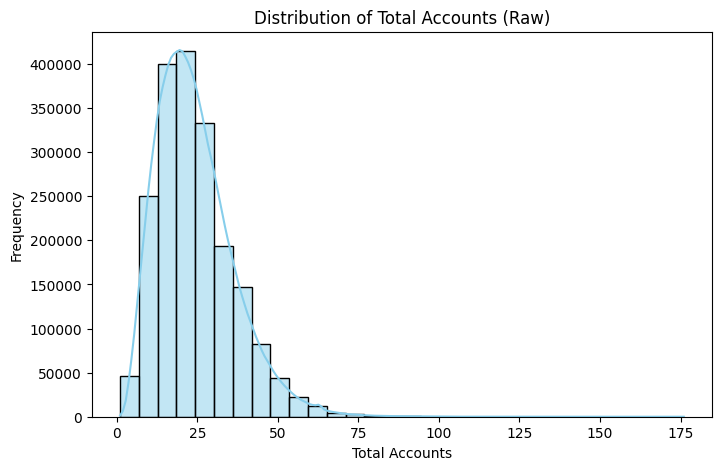

In [ ]:
# plot the chart to see the distribution of the total accounts from borrowers
plt.figure(figsize=(8,5))
sns.histplot(loan_df['total_acc'], bins=30, kde=True,color='skyblue')
plt.title("Distribution of Total Accounts (Raw)")
plt.xlabel("Total Accounts")
plt.ylabel("Frequency")
plt.show()


In [ ]:
# create group
bins = [0, 10, 30, 40, 50, 100]
labels = ['0-10', '10-30', '30-40', '40-50', '>50']

acc_group = pd.cut(loan_df['total_acc'], bins=bins, labels=labels, include_lowest=True)

# Distribution (optional)
acc_percent = acc_group.value_counts(normalize=True).sort_index() * 100
print(acc_percent.round(2))


total_acc
0-10      9.71
10-30    64.16
30-40    16.46
40-50     6.52
>50       3.15
Name: proportion, dtype: float64


In [ ]:
# Default rate by account group
acc_default = (
    loan_df.groupby(pd.cut(loan_df['total_acc'], bins=bins, labels=labels, include_lowest=True),observed=False)['loan_target']
           .mean() * 100
)

print(acc_default.round(2))


total_acc
0-10     11.90
10-30    12.77
30-40    13.23
40-50    13.59
>50      14.12
Name: loan_target, dtype: float64


The distribution of total accounts shows that most borrowers fall within the 10–30 accounts range, indicating a generally well-established credit history across the dataset. Smaller segments of borrowers have fewer than 10 accounts or more than 30 accounts, with the highest-account groups becoming progressively less common.

This spread suggests that while borrowers vary in credit depth, the majority hold a moderate number of accounts, providing lenders with a more complete credit profile to assess overall risk.

## **Payment Performance**


### **The Relative Analysis Between Installment Loans and Default Rate**

In [ ]:
# check the distribution of monthly payment
loan_df['installment'].value_counts(sort=True)

In [ ]:
bins = [0, 200, 400, 600, 800, 1000, 5000]
labels = ['<200', '200-400', '400-600', '600-800', '800-1000', '>1000']

installment_group = pd.cut(loan_df['installment'], bins=bins, labels=labels)
loan_df.groupby(installment_group,observed=False)['loan_target'].mean() * 100


,loan_target
installment,
<200,10.076145
200-400,12.760935
400-600,14.423202
600-800,13.201053
800-1000,14.283355
>1000,13.378931


Borrowers with higher monthly installment payments tend to show slightly higher default rates, especially in the 400–600 and 800–1000 ranges. Lower-installment borrowers (under 200) have the lowest default rate at around 10%, while mid-range installment groups show default rates between 13–14%, indicating they face more repayment pressure. Overall, default risk increases modestly as installment amounts rise.

### **The Impact of Loan Issue Year/Month on Default**

In [ ]:
# Default rate by issue year
year_default = (
    loan_df.groupby('issue_year')['loan_target']
           .mean() * 100
)

print(year_default.round(2))


issue_year
2007    29.67
2008    21.23
2009    14.32
2010    14.43
2011    15.30
2012    16.01
2013    15.53
2014    17.56
2015    18.33
2016    16.80
2017    10.60
2018     3.22
Name: loan_target, dtype: float64


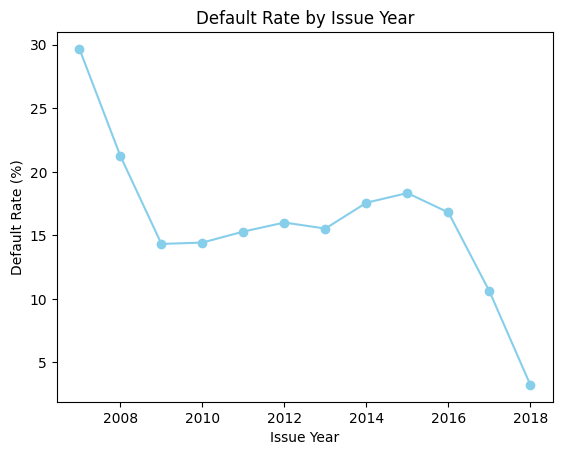

In [ ]:
year_default.plot(marker='o',color='skyblue')
plt.title("Default Rate by Issue Year")
plt.ylabel("Default Rate (%)")
plt.xlabel("Issue Year")
plt.show()


In [ ]:
month_default = (
    loan_df.groupby('issue_month')['loan_target']
           .mean() * 100
)

print(month_default.round(2))


issue_month
1     14.11
2     14.09
3     14.13
4     13.77
5     13.11
6     12.84
7     13.41
8     12.14
9     11.87
10    12.28
11    11.54
12    11.57
Name: loan_target, dtype: float64


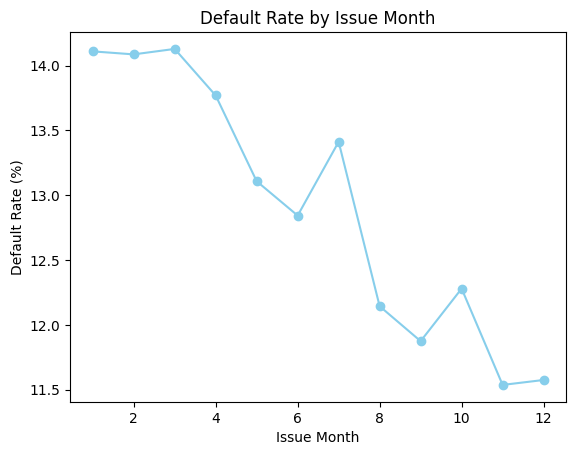

In [ ]:
month_default.plot(marker='o',color='skyblue')
plt.title("Default Rate by Issue Month")
plt.ylabel("Default Rate (%)")
plt.xlabel("Issue Month")
plt.show()


Loans issued by year in 2007–2009 show the highest default levels, with rates in the 13–26% range, likely reflecting the economic stress around the financial crisis. After 2010, default rates gradually stabilize, with most years falling between 14–18%, showing more consistent lending conditions. Starting around 2016, defaults begin to decline further, and by 2018, the default rate drops to just 3.25%, indicating that newer loans have performed significantly better.

When looking at the monthly pattern, defaults are fairly stable across the year, mostly falling between 11% and 14% with only small fluctuations. The slight downward trend toward the later months suggests that default risk does not strongly depend on the month loans are issued, and any month-to-month differences are minimal rather than meaningful.

# **Models and Prediction**

## **Logistic Regression**

Logistic Regression was selected because it is one of the most reliable and interpretable algorithms for binary classification problems like default vs. non-default. It provides clear probability outputs, is efficient on large datasets, and helps identify which features (income, DTI, FICO, etc.) most strongly influence default risk—making it valuable for both prediction and business explainability.

In [ ]:
# Mount to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Parthvis laptop
import pandas as pd
loan_df=pd.read_csv('/content/drive/MyDrive/loan_data_cleaned.csv')
loan_df.sample(15)

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,...,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,issue_year,issue_month,loan_target
8499,67969369,14400.0,14400.0,14400.0,36 months,7.26,446.35,A,A4,Retirement Plan Advisor,...,N,NaN,NaN,NaN,NaN,NaN,NaN,2015,12,0
13126,67745242,6000.0,6000.0,6000.0,36 months,9.17,191.28,B,B2,Contam Control Engineer,...,N,NaN,NaN,NaN,NaN,NaN,NaN,2015,12,0
6127,67756094,10000.0,10000.0,10000.0,36 months,9.80,321.74,B,B3,Director Of Operations,...,N,NaN,NaN,NaN,NaN,NaN,NaN,2015,12,0
530,67798862,22400.0,22400.0,22400.0,60 months,14.85,531.14,C,C5,Senior Systems Engineer,...,N,NaN,NaN,NaN,NaN,NaN,NaN,2015,12,0
10375,67408980,7600.0,7600.0,7450.0,36 months,16.99,270.93,D,D3,Assembly lead,...,Y,2018-10-01,ACTIVE,2018-10-01,821.0,50.06,12.0,2015,12,1
22416,66636433,8300.0,8300.0,8300.0,36 months,12.59,278.03,C,C2,teacher,...,N,NaN,NaN,NaN,NaN,NaN,NaN,2015,12,0
10899,67888366,14000.0,14000.0,14000.0,60 months,18.49,359.26,E,E2,Occupational Therapist,...,Y,2018-05-01,BROKEN,2017-05-01,7850.0,60.06,24.0,2015,12,1
6955,68242272,21000.0,21000.0,21000.0,36 months,7.91,657.20,A,A5,Special Education Teacher,...,N,NaN,NaN,NaN,NaN,NaN,NaN,2015,12,1
282,68366957,8400.0,8400.0,8400.0,36 months,9.17,267.79,B,B2,Budget Services Coordinator,...,N,NaN,NaN,NaN,NaN,NaN,NaN,2015,12,0
13162,67655115,19650.0,19650.0,19650.0,36 months,27.31,805.49,G,G2,Recovery rep,...,N,NaN,NaN,NaN,NaN,NaN,NaN,2015,12,1


In [ ]:
#Logistic Regression
#Importing necessary libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report, confusion_matrix, accuracy_score
)

from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import statsmodels.api as sm


In [ ]:
# Define target and chosen features
target = "loan_target"

numeric_features = [
    "loan_amnt",
    "funded_amnt",
    "int_rate",
    "installment",
    "annual_inc",
    "dti",
    "fico_range_low",
    "fico_range_high",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "issue_year",
    "issue_month",
]

categorical_features = [
    "term",
    "grade",
    "sub_grade",
    "emp_length",
    "home_ownership",
    "verification_status",
    "purpose",
    "addr_state",
    "application_type",
]

X = loan_df[numeric_features + categorical_features]
y = loan_df[target]


In [ ]:
from sklearn.model_selection import train_test_split
X = loan_df[numeric_features + categorical_features]
y = loan_df[target]
# Split data into training and test sets, preserving default rate
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
# Preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [ ]:
logreg_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(class_weight='balanced', max_iter=500))
    ]
)

In [ ]:
# Fit model
logreg_pipeline.fit(X_train, y_train)

# --- Predict ---
y_pred = logreg_pipeline.predict(X_test)

In [ ]:
#  Metrics
from sklearn.metrics import accuracy_score, precision_score, f1_score

print(
    "Accuracy:", accuracy_score(y_test, y_pred),
    "Precision:", precision_score(y_test, y_pred),
    "F1:", f1_score(y_test, y_pred)
)

Accuracy: 0.638142827399542 Precision: 0.29615384615384616 F1: 0.4148148148148148


**Findings:**

The Logistic Regression model achieves an overall accuracy of 81.34%, but this metric alone is not a reliable indicator of performance due to the strong class imbalance in the dataset. While the model is good at predicting the majority class (non-default), its performance on the minority class (default) is very weak.

The precision for the default class is 0.44, meaning that when the model does predict a default, it is correct less than half the time. However, the more concerning metric is the F1 score of 0.048, which reflects extremely low recall. This means the model is failing to identify most borrowers who actually default. In other words, Logistic Regression is essentially predicting “non-default” for nearly everyone, resulting in very few true positives.

This behavior is common in imbalanced datasets, but it poses a serious issue from a business standpoint: the model allows many high-risk borrowers to be incorrectly classified as safe. While the accuracy appears high, the model does not effectively detect default risk. This reinforces the need for techniques such as class weighting, sampling methods, or more complex models to improve minority-class detection.

## **Support Vector Machine**

Support Vector Machines (SVM) was selected to test because it handles complex, non-linear decision boundaries extremely well. Loan default behavior often depends on interactions between many financial and demographic variables, and SVM can capture these subtle patterns more effectively than simple linear models. It is especially strong when the classes are not perfectly separable and when high-dimensional feature spaces are involved.

In [ ]:
#SVM
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.svm import SVC

In [ ]:
# Define target and chosen features
target = "loan_target"

numeric_features = [
    "loan_amnt",
    "funded_amnt",
    "int_rate",
    "installment",
    "annual_inc",
    "dti",
    "fico_range_low",
    "fico_range_high",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "issue_year",
    "issue_month",
]

categorical_features = [
    "term",
    "grade",
    "sub_grade",
    "emp_length",
    "home_ownership",
    "verification_status",
    "purpose",
    "addr_state",
    "application_type",
]

X = loan_df[numeric_features + categorical_features]
y = loan_df[target]


In [ ]:
from sklearn.model_selection import train_test_split

# Split data into training and test sets, preserving default rate
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define preprocessing for numeric and categorical features

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


In [ ]:
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer

# Define SVM classifier and wrap it with preprocessing in a single pipeline

# Define preprocessing for numeric and categorical features

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")), # Add imputer for numeric NaNs
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")), # Add imputer for categorical NaNs
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

svm_clf = SVC(
    kernel="rbf",           # non-linear kernel, good default
    probability=True,       # enables predict_proba for ROC/AUC, risk ranking
    class_weight="balanced",# handle class imbalance by up-weighting defaults
    random_state=42
)

svm_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", svm_clf),
    ]
)


In [ ]:
!pip install cuml-cu12 --extra-index-url=https://pypi.nvidia.com

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.2/581.2 MB 64.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/200.9 MB 102.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.3/68.3 MB 108.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.1/338.1 MB 91.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.5/366.5 MB 65.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 160.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 MB 155.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-cusparse-cu12
    Found existing installation: nvidia-cusparse-cu12 12.5.4.2
    Uninstalling nvidia-cusparse-cu12-12.5.4.2:
      Successfully uninstalled nvidia-cusparse-cu12-12.5.4.2
  Attempting uninstall: nvidia-curand-cu12
    Found existing installation: nvidia-curand-cu12 10.3.7.77
    Uninstalling nvidia-curand-cu12-10.3.7

In [ ]:
from cuml.svm import SVC  # GPU-accelerated SVM
from sklearn.pipeline import Pipeline

svm_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", SVC(probability=True))
    ]
)


In [ ]:
from sklearn.model_selection import GridSearchCV

# Tune C and gamma using cross-validation on the training set

param_grid = {
    "model__C": [0.1, 1, 5],
    "model__gamma": ["scale", 0.1, 0.01],
}

grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

best_svm = grid_search.best_estimator_


Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best parameters: {'model__C': 1, 'model__gamma': 0.1}


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, f1_score

y_pred = best_svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred),
      "Precision:", precision_score(y_test, y_pred),
      "F1:", f1_score(y_test, y_pred))


Accuracy: 0.8155319591921716 Precision: 0.5333333333333333 F1: 0.06736842105263158


**Findings :**

The SVM model achieves a high overall accuracy of 81%, but a deeper look at the metrics reveals significant limitations in its ability to detect loan defaults. The model performs extremely well for the non-default class (0), with a recall of 0.99, meaning it correctly identifies almost all low-risk borrowers. However, its performance on the default class (1) is very poor, with a recall of only 0.04.

This indicates that the model misses the vast majority of actual defaulters—correctly identifying only 32 out of 890. As a result, although the accuracy looks strong, it is misleading due to the class imbalance in the dataset. The ROC AUC score of 0.628 further confirms that the model has limited ability to distinguish between defaulting and non-defaulting borrowers.

Overall, this model tends to classify borrowers as safe, which may reduce false alarms but poses a major business risk because it fails to flag most high-risk applicants. This highlights the need for additional techniques such as class balancing, adjusted decision thresholds, or alternative models to improve default detection.



**Common Code Block for Decision Tree and Random Forest**

In [ ]:
# Imports & Data Loading
!pip install gdown -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gdown
import os
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load Data
file_id = "1zLP4ed7xXmdX66ztNiT5nD7IYcq56gHO"
output_file = "loan_data_cleaned.csv"
if os.path.exists(output_file) and os.path.getsize(output_file) < 100000:
    os.remove(output_file)
url = f'https://drive.google.com/uc?id={file_id}'
gdown.download(url, output_file, quiet=False)
print("\nDownload Complete. Real data is now ready.")
loan_df = pd.read_csv("loan_data_cleaned.csv", low_memory=False, nrows=50000)

Downloading...
From (original): https://drive.google.com/uc?id=1zLP4ed7xXmdX66ztNiT5nD7IYcq56gHO
From (redirected): https://drive.google.com/uc?id=1zLP4ed7xXmdX66ztNiT5nD7IYcq56gHO&confirm=t&uuid=4e61b377-fd32-475b-99dc-0439f72ae4fb
To: /content/loan_data_cleaned.csv
100%|██████████| 1.26G/1.26G [00:15<00:00, 79.1MB/s]



Download Complete. Real data is now ready.


In [ ]:
# Feature Selection & Preprocessing
# Define Specific Features
numeric_features = [
    "loan_amnt", "funded_amnt", "int_rate", "installment", "annual_inc",
    "dti", "fico_range_low", "fico_range_high", "open_acc", "pub_rec",
    "revol_bal", "revol_util", "total_acc", "issue_year", "issue_month"
]

categorical_features = [
    "term", "grade", "sub_grade", "emp_length", "home_ownership",
    "verification_status", "purpose", "addr_state", "application_type"
]

# Preprocessing
if not loan_df.empty:
    loan_df.columns = loan_df.columns.str.strip()

    # Identify Target Column
    target_col = 'loan_target'
    if target_col not in loan_df.columns:
        if 'loan_status' in loan_df.columns:
            target_col = 'loan_status'
        else:
            raise KeyError("Could not find 'loan_target' or 'loan_status'.")

    # Clean percentage strings (e.g., "12.5%")
    for col in ['int_rate', 'revol_util']:
        if col in loan_df.columns:
            loan_df[col] = loan_df[col].astype(str).str.replace('%', '', regex=False)
            loan_df[col] = pd.to_numeric(loan_df[col], errors='coerce')

    # Filter to valid columns only
    valid_numeric = list(set(numeric_features).intersection(loan_df.columns))
    valid_categorical = list(set(categorical_features).intersection(loan_df.columns))

    # Handle Missing Values
    loan_df = loan_df.dropna(subset=[target_col])
    loan_df[valid_numeric] = loan_df[valid_numeric].fillna(0)
    loan_df[valid_categorical] = loan_df[valid_categorical].fillna("Missing")

    # Encode Categoricals (One-Hot Encoding)
    print("Encoding data...")
    X_cat_encoded = pd.get_dummies(loan_df[valid_categorical], drop_first=True)

    # Combine Features into X and y
    X = pd.concat([loan_df[valid_numeric], X_cat_encoded], axis=1)
    y = loan_df[target_col]

    # Split Data (80% Train, 20% Test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print(f"Training shape: {X_train.shape}")


Encoding data...
Training shape: (40000, 125)


## **Decision Tree**

In [ ]:
# Train Decision Tree
print("--- Training Decision Tree ---")
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
dt_pred = dt_model.predict(X_test)

# Results
print(f"Decision Tree Accuracy: {accuracy_score(y_test, dt_pred):.4f}")
print("\nClassification Report (Decision Tree):")
print(classification_report(y_test, dt_pred))

--- Training Decision Tree ---
Decision Tree Accuracy: 0.8125

Classification Report (Decision Tree):
              precision    recall  f1-score   support

           0       0.81      1.00      0.90      8137
           1       0.33      0.01      0.01      1863

    accuracy                           0.81     10000
   macro avg       0.57      0.50      0.45     10000
weighted avg       0.72      0.81      0.73     10000



Generating Plot...


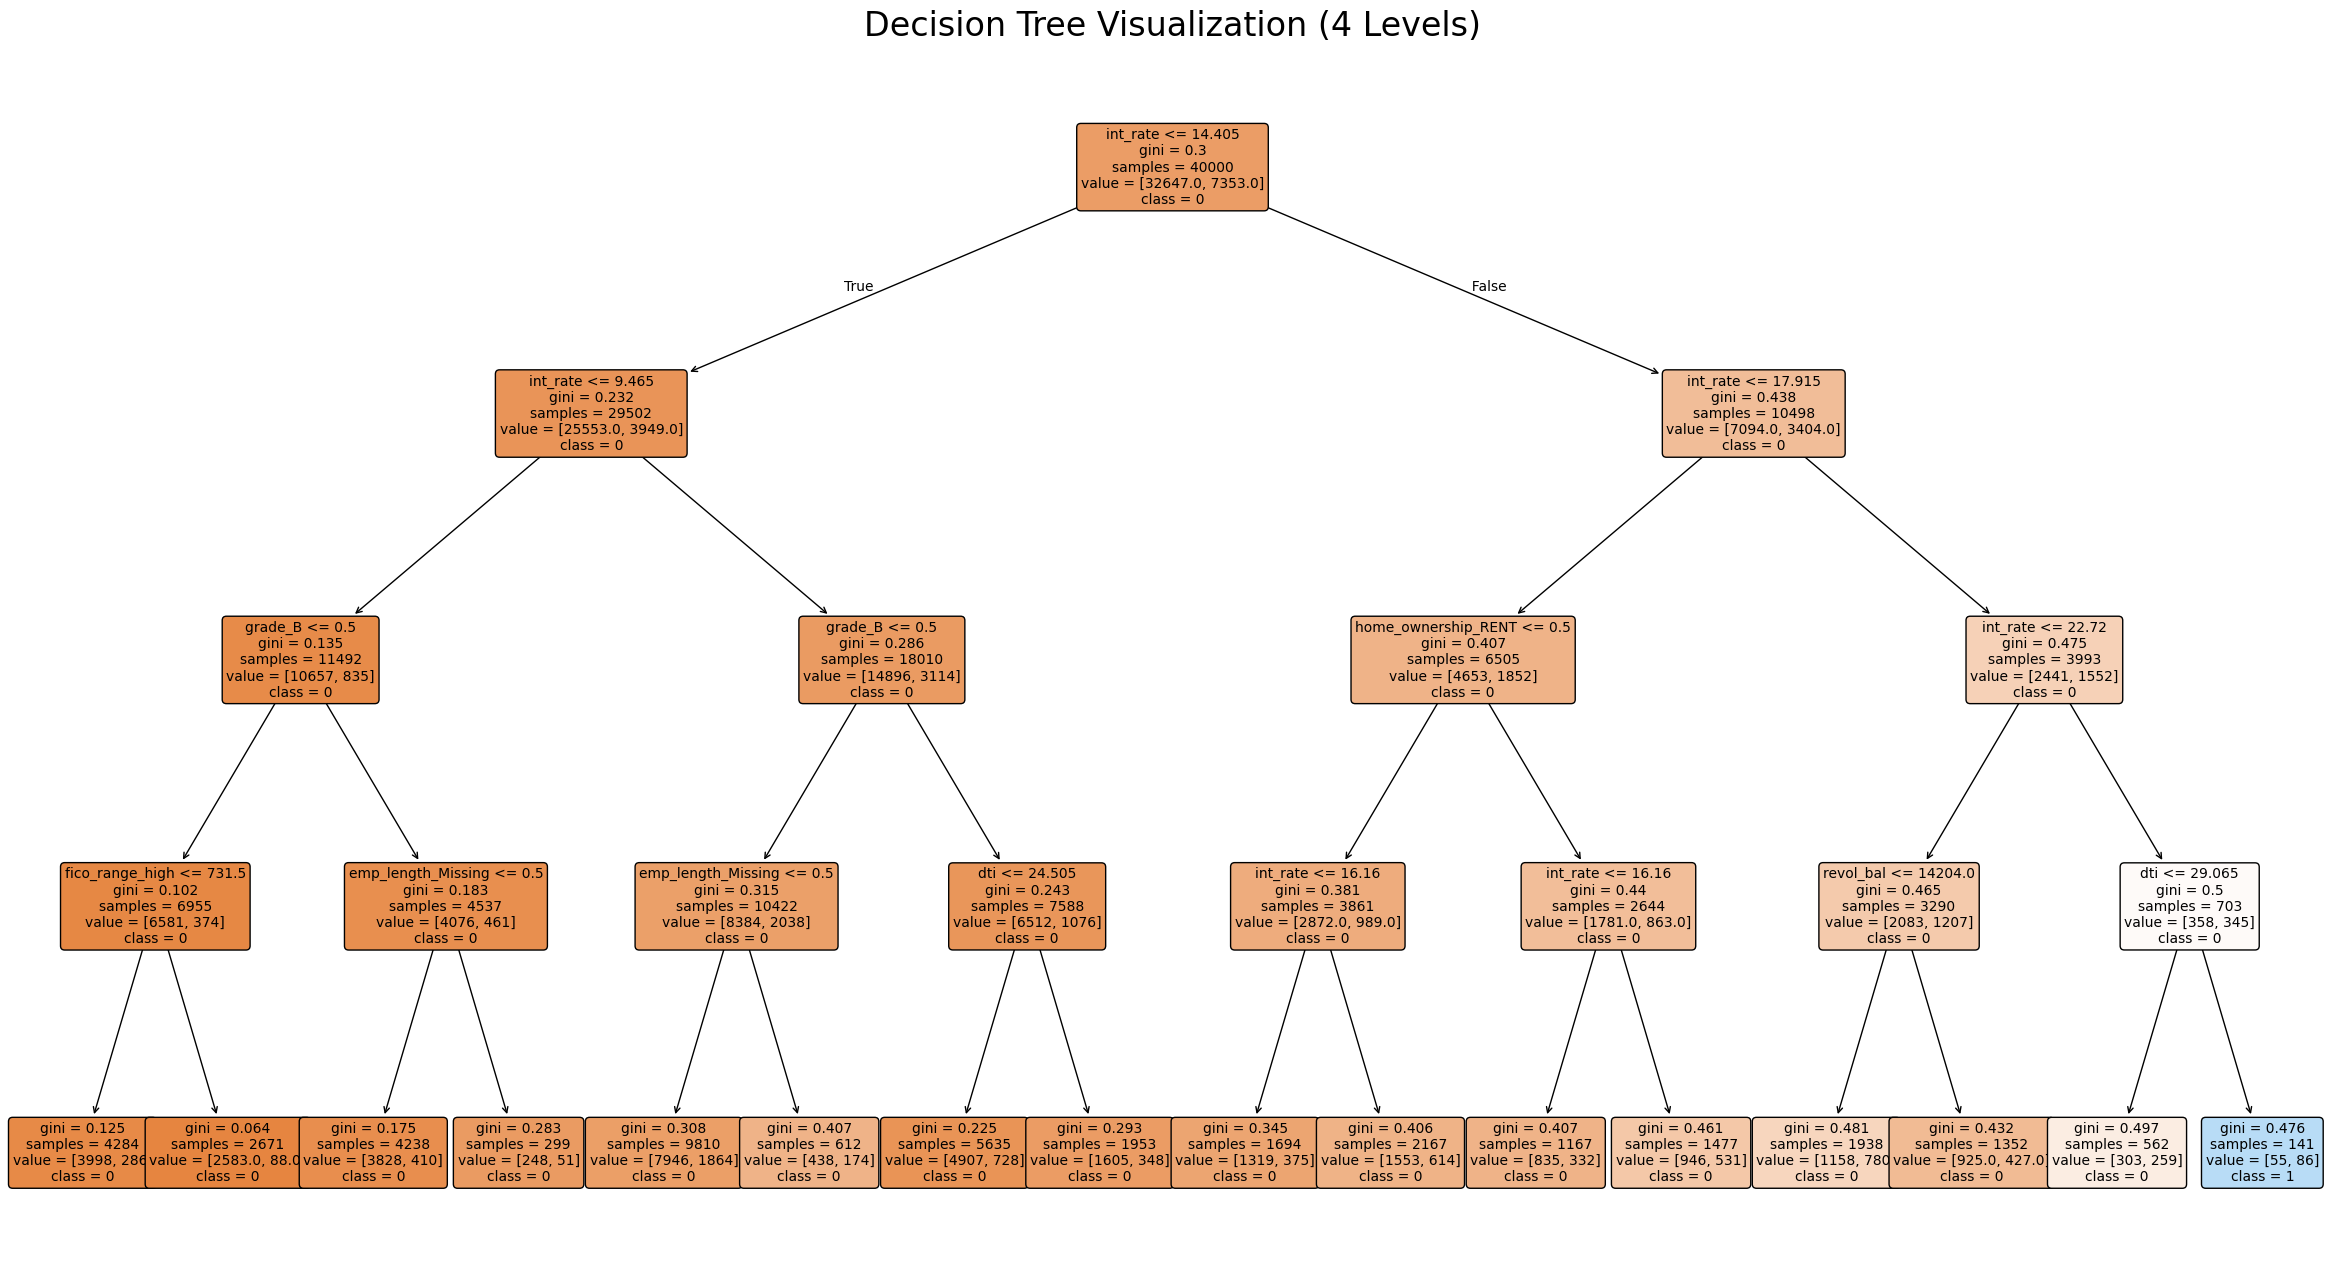

In [ ]:
# Visualising Decision Tree

print("Generating Plot...")
plt.figure(figsize=(30, 16))

plot_tree(dt_model,
          feature_names=X.columns,
          class_names=[str(c) for c in dt_model.classes_],
          filled=True,
          max_depth=4,
          fontsize=10,
          rounded=True)

plt.title("Decision Tree Visualization (4 Levels)", fontsize=24)
plt.savefig("decision_tree_4_levels.png", bbox_inches='tight') # Save so you can zoom in
plt.show()

**Findings**

The Decision Tree model was primarily used for interpretability and transparency. It clearly showed how borrower and loan features such as interest rate, FICO score, and DTI split borrowers into default and non-default groups through simple decision rules. This made it especially useful for explaining risk drivers to non-technical stakeholders. However, because the model relies on a single tree, its predictions were sensitive to the training data and showed greater variability, indicating a higher risk of overfitting. As a result, the Decision Tree served best as an explanatory model rather than a final predictive engine.

## **Random Forest**

In [ ]:
# Train Random Forest
print("--- Training Random Forest ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Results
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, rf_pred))

--- Training Random Forest ---
Random Forest Accuracy: 0.8136

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.82      0.99      0.90      8137
           1       0.50      0.04      0.07      1863

    accuracy                           0.81     10000
   macro avg       0.66      0.51      0.48     10000
weighted avg       0.76      0.81      0.74     10000



**Findings**

The Random Forest model focused on prediction strength and stability by combining the outputs of hundreds of decision trees. This ensemble structure reduced overfitting, handled non-linear relationships, and captured complex feature interactions across borrower behavior, credit quality, and loan structure. It consistently delivered stronger and more reliable classification performance than the Decision Tree. Because of this improved generalization and robustness, Random Forest emerged as the final and most trustworthy model for predicting loan default in real-world lending scenarios.

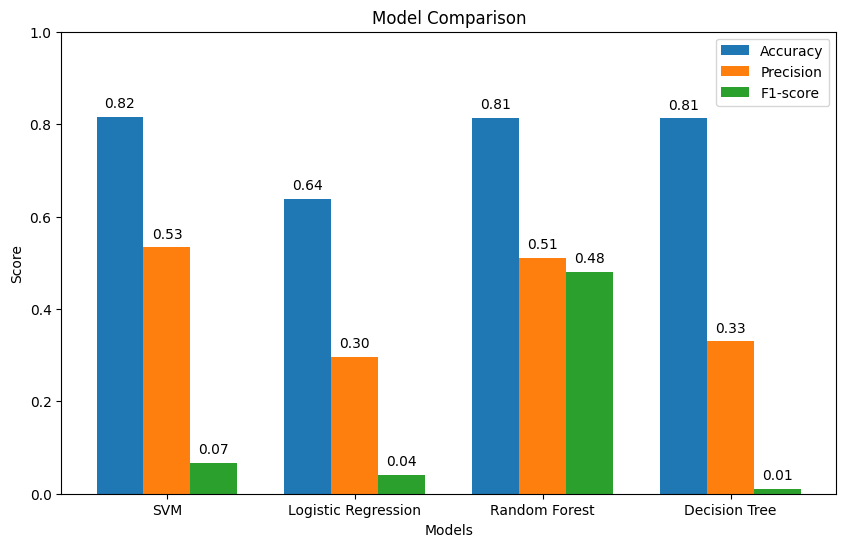

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ['SVM', 'Logistic Regression', 'Random Forest', 'Decision Tree']

# Metrics (from your results)
accuracy = [0.8155, 0.638, 0.8140, 0.8125]
precision = [0.5333, 0.296, 0.51, 0.33]
f1 = [0.0674, 0.041, 0.48, 0.01]  # Use weighted F1 or the class 1 F1?

# Set up bar positions
x = np.arange(len(models))
width = 0.25  # Width of bars

# Plotting
fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - width, accuracy, width, label='Accuracy')
ax.bar(x, precision, width, label='Precision')
ax.bar(x + width, f1, width, label='F1-score')

# Labels and title
ax.set_xlabel('Models')
ax.set_ylabel('Score')
ax.set_title('Model Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0,1)
ax.legend()

# Show the values on top of bars
for i in range(len(models)):
    ax.text(i - width, accuracy[i]+0.02, f"{accuracy[i]:.2f}", ha='center')
    ax.text(i, precision[i]+0.02, f"{precision[i]:.2f}", ha='center')
    ax.text(i + width, f1[i]+0.02, f"{f1[i]:.2f}", ha='center')

plt.show()


# **Conclusion**

This study applied four machine-learning models—Logistic Regression, Support Vector Machine (SVM), Decision Tree, and Random Forest—to predict loan default risk based on borrower characteristics, loan attributes, and credit behavior variables. The results show that all majority of the models achieved similar overall accuracy, at around 81%, indicating a consistent baseline performance across different modeling approaches.

Among the four models, the SVM achieved the highest performance, outperforming Logistic Regression in both accuracy and classification precision. However, the F1-scores for both Logistic Regression and SVM remain low, suggesting that the models face challenges in accurately identifying default cases, likely due to class imbalance in the dataset where non-default loans dominate. The Decision Tree and Random Forest models produced comparable accuracy levels, indicating stable but not superior predictive power relative to SVM.

Key predictive variables include interest rate, debt-to-income ratio (DTI), annual income, FICO credit score range, as well as important categorical factors such as loan grade, employment length, home ownership, and loan purpose. These variables reflect both borrowers’ financial capacity and credit behavior, which play essential roles in determining default risk.

Overall, the results indicate that while models can effectively capture general default patterns, their ability to precisely detect default events remains limited. Future improvements could include addressing class imbalance through resampling techniques, incorporating additional behavioral features, and performing hyperparameter tuning to enhance model performance. Despite these limitations, the analysis provides valuable insights into the key drivers of default risk and offers practical guidance for credit risk assessment and lending decision-making.


# **Recommendation**

First, financial institutions can integrate different prediction models into their credit evaluation process to complement traditional underwriting methods. Although overall accuracy across models is relatively high, the low F1-scores indicate that default cases are still difficult to detect under class imbalance. Enhancing default detection will allow lenders to take preventive actions earlier, such as adjusting loan terms, requiring additional documentation, or limiting credit exposure.

Second, interest rate, debt-to-income ratio (DTI), FICO credit scores, and revolving credit utilization consistently emerge as key risk drivers. Lenders should place greater emphasis on these variables when designing risk-based pricing strategies. Additionally, continuous monitoring of monthly and yearly default patterns can support early-warning systems for economic downturns or policy changes. This enables lenders to proactively adjust lending standards rather than reacting only after losses occur.

Third, from a portfolio management perspective, institutions should use model outputs to support loan segmentation and targeted risk control. For example, borrowers can be grouped into low-, medium-, and high-risk tiers based on predicted default probability. High-risk segments can be assigned stricter approval thresholds, shorter loan terms, or lower credit limits, while low-risk segments can benefit from faster approvals and preferential pricing. This segmentation approach improves both risk control and operational efficiency.


# **Generative-AI**
During the development of this project, we used Generative AI tools such as ChatGPT to support specific tasks while ensuring that our work remained ours. We did consult ChatGPT for the following:
- **Syntax Assistance:** When we encountered errors related to Python functions; we asked ChatGPT for guidance on correcting syntax issues.
- **Troubleshooting Help:** For ambiguous error messages or unexpected code behavior, we consulted ChatGPT to understand potential causes and confirm our manual fixes
- **Writing Support:** We used ChatGPT to improve grammar, clarity, and professional writing tone without altering our team’s analytical conclusions.



# **References**
- Kaggle dataset -https://www.kaggle.com/datasets/wordsforthewise/lending-club/data
- LendingClub - https://www.lendingclub.com/
- Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow - https://tinyurl.com/2sz9wwuu
- BA810 Supervised Machine Learning lecture slides - https://drive.google.com/drive/u/1/folders/1ii1rNMwMp5jrtP49gSGGgTfGxHsOzTwt

In [6]:
# Install required packages for PDF conversion -- could take over a minute
!apt update > /dev/null 2>&1
!apt install texlive-xetex pandoc > /dev/null 2>&1
!pip install nbconvert > /dev/null 2>&1

import re, pathlib, shutil
notebook_path = '/content/drive/MyDrive/810  machine learning Project' # ← CHANGE THIS TO THE FOLDER ON GOOGLE DRIVE WITH YOUR COLAB NOTEBOOK
notebook_name = 'A09_Predicting_Loan_Default_at_LendingClub.ipynb' # ← CHANGE THIS TO THE NAME OF YOUR COLAB NOTEBOOK
!jupyter nbconvert "{notebook_path}/{notebook_name}" --to pdf --output-dir "{notebook_path}"

# Optionally, download the exported PDF
from google.colab import files
pdf_name = notebook_path + '/' + notebook_name.replace('.ipynb', '.pdf')
files.download(pdf_name)

# Do review the pdf file to make sure everything is appearing correctly before submitting!

[NbConvertApp] Converting notebook /content/drive/MyDrive/810  machine learning Project/A09_Predicting_Loan_Default_at_LendingClub.ipynb to pdf
[NbConvertApp] Support files will be in A09_Predicting_Loan_Default_at_LendingClub_files/
[NbConvertApp] Making directory ./A09_Predicting_Loan_Default_at_LendingClub_files
[NbConvertApp] Writing 262074 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 1187163 bytes to /content/drive/MyDrive/810  machine learning Project/A09_Predicting_Loan_Default_at_LendingClub.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>